# 🗂️ Notebook — Modélisation Churn & Segmentation Clients RFM
---
## Partie 1 — Prétraitement des données

In [9]:
# ============================================================
# CELLULE 1 — Imports & Chargement des données
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

df = pd.read_csv(r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\processed\data_clean.csv')

print(f'Données chargées : {df.shape}')
print(f'\nNaN par colonne :')
manquants = df.isnull().sum()
print(manquants[manquants > 0])

Données chargées : (4372, 59)

NaN par colonne :
MonetaryTotal                44
AvgDaysBetweenPurchases      79
Age                        1311
SupportTicketsCount         130
SatisfactionScore           229
MonetaryPerDay               44
AvgBasketValue               44
dtype: int64


In [5]:
# ============================================================
# CELLULE 2 — Suppression du Data Leakage
# ============================================================
# Règle : toute feature qui contient ou dérive du Churn
# doit être supprimée AVANT le split.
#
# ChurnRiskCategory  → construite à partir du churn
# CustomerType       → valeur 'Perdu' = client churné
# AccountStatus      → 'Closed' = compte fermé = churné
# TenureRatio        → Recency / CustomerTenureDays (dérivée de Recency)
# MonetaryPerDay     → MonetaryTotal / (Recency+1) (dérivée de Recency)

leakage_cols = [
    'ChurnRiskCategory', 'CustomerType', 'AccountStatus',
    # 'TenureRatio', 'MonetaryPerDay'
]

df_clean = df.drop(columns=[c for c in leakage_cols if c in df.columns])

print(f'Shape avant : {df.shape}')
print(f'Shape après : {df_clean.shape}')
print(f'Supprimées  : {[c for c in leakage_cols if c in df.columns]}')

Shape avant : (4372, 59)
Shape après : (4372, 59)
Supprimées  : []


In [10]:
# ============================================================
# CELLULE 3 — Séparation X / y + Split Train/Test
# ============================================================
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'\nDistribution Churn :')
print(y.value_counts(normalize=True).round(3) * 100)

# stratify=y → préserve la proportion 66%/33% dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nX_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'\nDistribution y_train : {y_train.value_counts().to_dict()}')
print(f'Distribution y_test  : {y_test.value_counts().to_dict()}')

X shape : (4372, 58)
y shape : (4372,)

Distribution Churn :
Churn
0    66.7
1    33.3
Name: proportion, dtype: float64

X_train : (3497, 58)
X_test  : (875, 58)

Distribution y_train : {0: 2334, 1: 1163}
Distribution y_test  : {0: 584, 1: 291}


In [87]:
# ============================================================
# CELLULE 4 — Target Encoding Country
# ============================================================
# fit sur X_train SEULEMENT → évite le leakage
if 'Country' in X_train.columns:
    temp = X_train.copy()
    temp['Churn'] = y_train.values
    target_mean = temp.groupby('Country')['Churn'].mean()

    X_train['Country_encoded'] = X_train['Country'].map(target_mean)
    X_test['Country_encoded']  = X_test['Country'].map(target_mean)

    # Pays absents dans train → moyenne globale de y_train
    moy = y_train.mean()
    X_train['Country_encoded'] = X_train['Country_encoded'].fillna(moy)
    X_test['Country_encoded']  = X_test['Country_encoded'].fillna(moy)

    X_train = X_train.drop(columns=['Country'])
    X_test  = X_test.drop(columns=['Country'])

    print(f'Country → Country_encoded (Target Encoding)')
    print(f'X_train : {X_train.shape}')
    print(f'X_test  : {X_test.shape}')

Country → Country_encoded (Target Encoding)
X_train : (3497, 58)
X_test  : (875, 58)


In [7]:
# ============================================================
# CELLULE 5 — Imputation des valeurs manquantes
# ============================================================
# fit sur X_train SEULEMENT → transform sur X_test
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'NaN restants X_train : {X_train.isnull().sum().sum()}')
print(f'NaN restants X_test  : {X_test.isnull().sum().sum()}')

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'United Kingdom'

In [89]:
# ============================================================
# CELLULE 6 — Suppression des Outliers Extrêmes (Z-score > 4)
# ============================================================
# - On calcule le Z-score sur X_train SEULEMENT (pas sur X_test)
# - On supprime les lignes aberrantes uniquement dans X_train / y_train
# - X_test reste intact

num_cols = X_train.select_dtypes(include='number').columns
X_train_tmp = X_train[num_cols].fillna(X_train[num_cols].median())
z_scores = np.abs(stats.zscore(X_train_tmp))

mask_ok = (z_scores < 4).all(axis=1)

print(f'Avant  : X_train = {X_train.shape}')
print(f'Outliers détectés : {(~mask_ok).sum()} clients')

X_train = X_train[mask_ok]
y_train = y_train[mask_ok]

print(f'Après  : X_train = {X_train.shape}')
print(f'X_test NON touché : {X_test.shape}')
print(f'\nDistribution y_train après : {y_train.value_counts().to_dict()}')

Avant  : X_train = (3497, 58)
Outliers détectés : 329 clients
Après  : X_train = (3168, 58)
X_test NON touché : (875, 58)

Distribution y_train après : {0: 2126, 1: 1042}


In [2]:
# ============================================================
# CELLULE 7 — Normalisation StandardScaler
# ============================================================
# fit sur X_train SEULEMENT → transform sur X_test
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f'X_train moyenne    : {X_train.mean().mean():.4f}  (doit être ≈ 0)')
print(f'X_train écart-type : {X_train.std().mean():.4f}  (doit être ≈ 1)')

os.makedirs(r'C:\Users\abdal\Desktop\projects\ML\ML_project\models', exist_ok=True)
joblib.dump(imputer, r'C:\Users\abdal\Desktop\projects\ML\ML_project\models\imputer.pkl')
joblib.dump(scaler,  r'C:\Users\abdal\Desktop\projects\ML\ML_project\models\scaler.pkl')
print('Imputer et Scaler sauvegardés')

NameError: name 'StandardScaler' is not defined

---
## Partie 2 — Segmentation Clients (Clustering RFM)

> Le clustering est réalisé sur les **données brutes** (`df`) à partir des 3 dimensions RFM :
> - **R** — Recency : jours depuis le dernier achat
> - **F** — Frequency : nombre de commandes
> - **M** — MonetaryTotal : montant total dépensé
>
> ⚠️ Recency est autorisée ici car le clustering est un exercice de **segmentation**, pas de prédiction (pas de contrainte de leakage).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Style des graphiques
sns.set_theme(style="whitegrid")

# 1. Chargement des données (ajustez le chemin si besoin)
df = pd.read_csv('../data/processed/data_clean.csv')

# 2. Sélection des colonnes RFM
rfm_cols = ['Recency', 'Frequency', 'MonetaryTotal']
df_rfm = df[rfm_cols].dropna().copy()

# 3. Transformation Logarithmique (pour écraser les valeurs extrêmes)
df_rfm_log = df_rfm.clip(lower=0).apply(np.log1p)

# 4. Standardisation (Mettre sur la même échelle)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm_log)

print(f"Données prêtes ! Dimensions : {X_scaled.shape}")

Données prêtes ! Dimensions : (4328, 3)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Style des graphiques
sns.set_theme(style="whitegrid")

# 1. Chargement des données (ajustez le chemin si besoin)
df = pd.read_csv('../data/processed/data_clean.csv')

# 2. Sélection des colonnes RFM
rfm_cols = ['Recency', 'Frequency', 'MonetaryTotal']
df_rfm = df[rfm_cols].dropna().copy()

# 3. Transformation Logarithmique (pour écraser les valeurs extrêmes)
df_rfm_log = df_rfm.clip(lower=0).apply(np.log1p)

# 4. Standardisation (Mettre sur la même échelle)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_rfm_log)

print(f"Données prêtes ! Dimensions : {X_scaled.shape}")

Données prêtes ! Dimensions : (4328, 3)


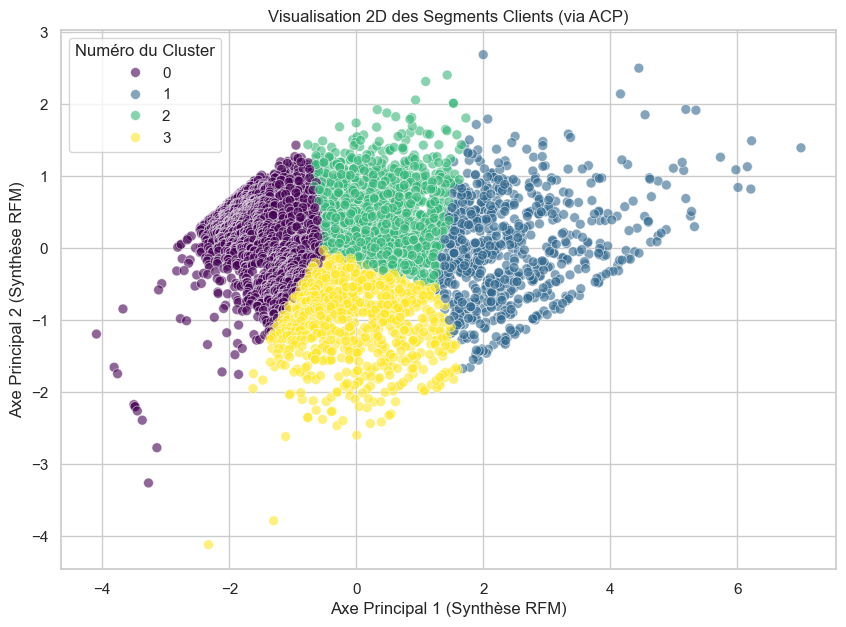


--- Profil moyen des clusters (Réalité Métier) ---
         Recency  Frequency  MonetaryTotal  Nb_Clients
Cluster                                               
0          173.0        1.0          272.8        1563
1            8.0       12.0         3540.1         745
2           58.0        4.0         1268.1        1156
3           16.0        2.0          485.0         864


In [9]:
# 1. On applique le K-Means définitif avec K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. On applique l'ACP pour réduire de 3D à 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_rfm['PCA_1'] = X_pca[:, 0]
df_rfm['PCA_2'] = X_pca[:, 1]

# 3. Dessin des clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_rfm, 
    x='PCA_1', 
    y='PCA_2', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.6,
    s=50
)
plt.title('Visualisation 2D des Segments Clients (via ACP)')
plt.xlabel('Axe Principal 1 (Synthèse RFM)')
plt.ylabel('Axe Principal 2 (Synthèse RFM)')
plt.legend(title='Numéro du Cluster')
plt.show()

# 4. Affichage du profil moyen de chaque groupe
print("\n--- Profil moyen des clusters (Réalité Métier) ---")
profils = df_rfm.groupby('Cluster')[rfm_cols].median().round(1)
profils['Nb_Clients'] = df_rfm.groupby('Cluster').size()
print(profils)

In [6]:
FEATURES_RFM = ['Recency', 'Frequency', 'MonetaryTotal']

# Colonnes de "Leakage" à exclure de la prédiction du Churn
LEAKAGE_CLF = [
    'ChurnRiskCategory', 'CustomerType', 'AccountStatus',
    'Recency', 'TenureRatio', 'MonetaryPerDay', 'FirstPurchaseDaysAgo', 
    'CustomerTenureDays', 'LoyaltyLevel'
]

ALL_SEGMENTS = ['Clients Champions', 'Clients Fidèles', 'Clients Perdus', 'Clients à Risque']
SEP = "=" * 62

def entrainer_clustering(df):
    print(f"\n{SEP}\n  ÉTAPE 1 — CLUSTERING RFM (K-Means)\n{SEP}")
    
    mask_rfm = df[FEATURES_RFM].notna().all(axis=1)
    df_rfm   = df.loc[mask_rfm, FEATURES_RFM + ['Churn']].copy()
    
    # Transformation mathématique pour K-Means
    df_rfm_log = df_rfm[FEATURES_RFM].clip(lower=0).apply(np.log1p)
    scaler_rfm = StandardScaler()
    X_rfm_sc   = scaler_rfm.fit_transform(df_rfm_log)

    # Entraînement K-Means (K=4 validé précédemment)
    k_optimal = 4
    kmeans_rfm = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
    kmeans_rfm.fit(X_rfm_sc)

    df_clust = df_rfm[FEATURES_RFM + ['Churn']].copy()
    df_clust['cluster'] = kmeans_rfm.labels_

    # Nommage des segments (Business Logic)
    profiles = df_clust.groupby('cluster')[FEATURES_RFM + ['Churn']].mean().round(2)
    def nommer(row):
        if row['Churn'] >= 0.60: return 'Clients Perdus'
        if row['Churn'] >= 0.15: return 'Clients à Risque'
        if row['Frequency'] >= profiles['Frequency'].median(): return 'Clients Champions'
        return 'Clients Fidèles'

    profiles['segment'] = profiles.apply(nommer, axis=1)
    df_clust['segment'] = df_clust['cluster'].map(profiles['segment'].to_dict())

    # Sauvegarde des modèles
    # joblib.dump(kmeans_rfm, os.path.join(MODELS_DIR, 'kmeans_rfm.pkl'))
    # joblib.dump(scaler_rfm, os.path.join(MODELS_DIR, 'scaler_rfm.pkl'))

    # Injection des résultats dans le DataFrame global pour aider XGBoost/RF
    df_enrichi = df.copy()
    df_enrichi['rfm_cluster'] = -1
    df_enrichi.loc[df_clust.index, 'rfm_cluster'] = df_clust['cluster'].values

    for seg in ALL_SEGMENTS:
        col = 'rfm_seg_' + seg.replace(' ', '_')
        df_enrichi[col] = 0.0
        mask_seg = df_clust.index[df_clust['segment'] == seg]
        df_enrichi.loc[mask_seg, col] = 1.0

    print(" -> K-Means entraîné avec succès. Segments injectés dans les données.")
    return df_enrichi, df_clust

Clients disponibles : 4372

Statistiques AVANT transformation :
       Recency  Frequency  MonetaryTotal
count   4372.0     4372.0         4372.0
mean      92.0        5.1         1898.5
std      100.8        9.3         8219.3
min        1.0        1.0        -4287.6
25%       17.0        1.0          293.4
50%       50.0        3.0          648.1
75%      143.0        5.0         1611.7
max      374.0      248.0       279489.0
  ⚠️  MonetaryTotal : 44 valeurs négatives → ramenées à 0 par clip

✅ Pipeline appliqué — shape finale : (4372, 3)


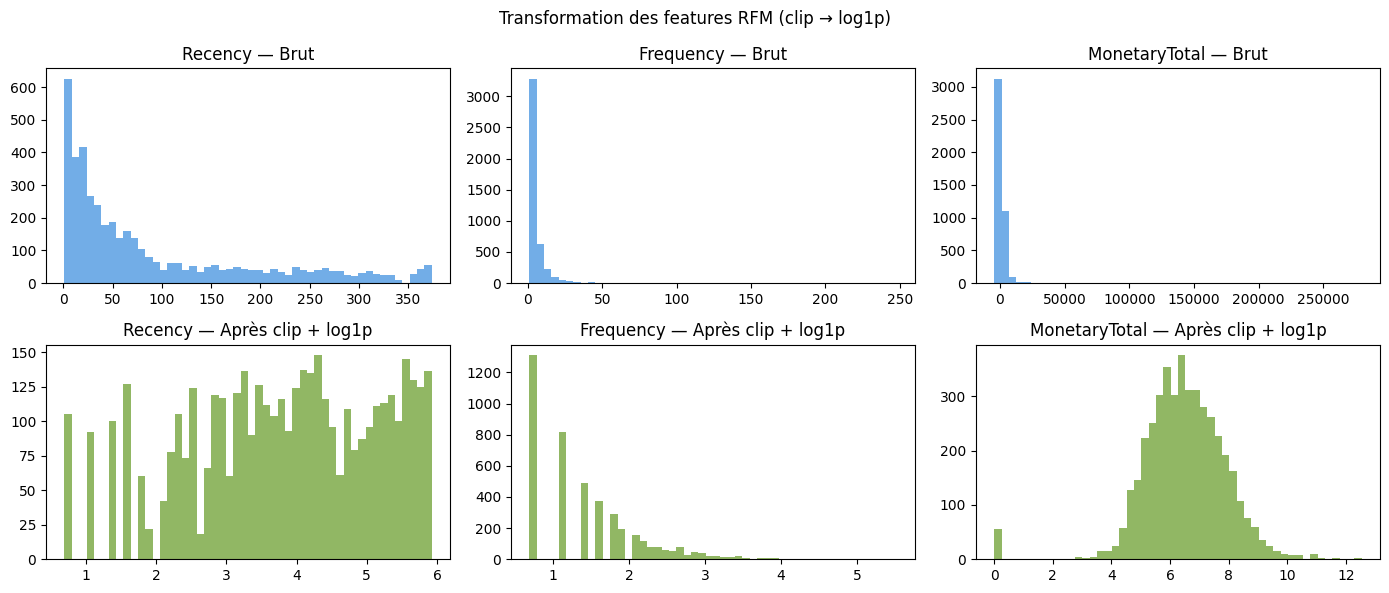

In [91]:
# ============================================================
# CELLULE 8 — Préparation des données RFM
# ============================================================
# Pipeline : clip(lower=0) → log1p → StandardScaler
#
# Pourquoi chaque étape ?
# 1. clip(lower=0)   → élimine les valeurs négatives qui rendent log1p = NaN
# 2. log1p           → compresse les distributions très skewed (outliers monétaires)
#                      sans log : K-Means crée des micro-clusters autour des outliers
# 3. StandardScaler  → met Recency (jours), Frequency (nb) et MonetaryTotal (£)
#                      sur la même échelle → distances euclidiennes non biaisées

features_rfm = ['Recency', 'Frequency', 'MonetaryTotal']

# 1. Source : df_clean (post-leakage) — colonnes RFM + Churn
df_rfm_raw = df_clean[features_rfm + ['Churn']].dropna(subset=features_rfm).reset_index(drop=True)

print(f"Clients disponibles : {len(df_rfm_raw)}")
print("\nStatistiques AVANT transformation :")
print(df_rfm_raw[features_rfm].describe().round(1))

# Vérifier les valeurs négatives
for col in features_rfm:
    n_neg = (df_rfm_raw[col] < 0).sum()
    if n_neg > 0:
        print(f"  ⚠️  {col} : {n_neg} valeurs négatives → ramenées à 0 par clip")

# 2. clip(lower=0) + log1p
df_rfm_log = df_rfm_raw[features_rfm].clip(lower=0).apply(np.log1p)

# 3. StandardScaler
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(df_rfm_log)

assert not np.isnan(X_rfm_scaled).any(), "❌ NaN détectés dans X_rfm_scaled !"
print(f"\n✅ Pipeline appliqué — shape finale : {X_rfm_scaled.shape}")

# Visualisation avant / après
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for idx, feat in enumerate(features_rfm):
    axes[0, idx].hist(df_rfm_raw[feat], bins=50, color='#378ADD', alpha=0.7)
    axes[0, idx].set_title(f'{feat} — Brut')
    axes[1, idx].hist(df_rfm_log[feat], bins=50, color='#639922', alpha=0.7)
    axes[1, idx].set_title(f'{feat} — Après clip + log1p')
plt.suptitle('Transformation des features RFM (clip → log1p)', fontsize=12)
plt.tight_layout()
plt.show()

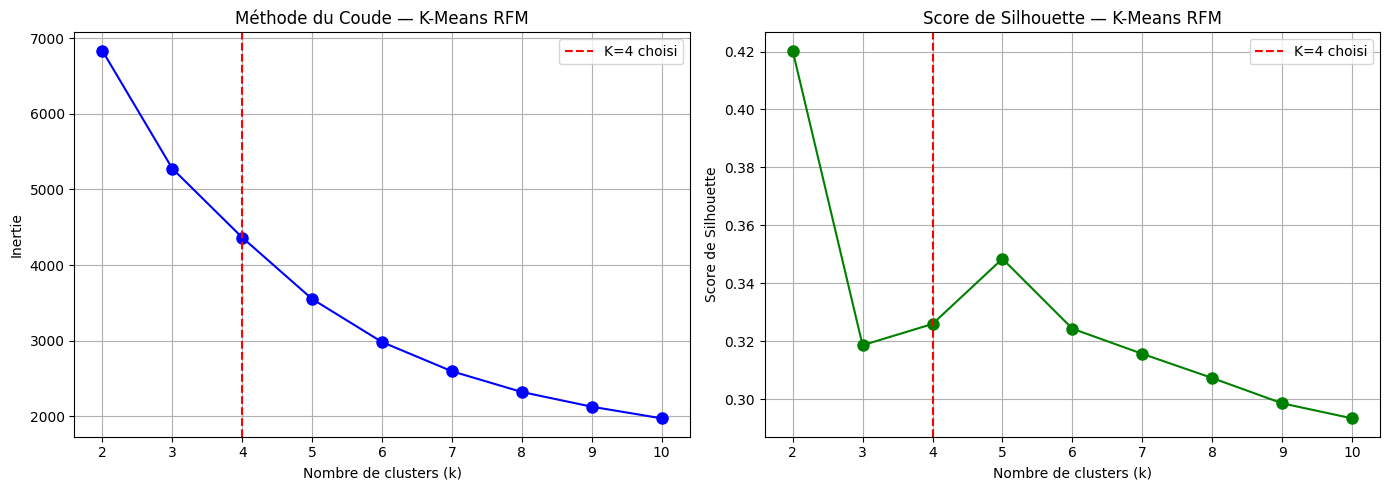


✅ K optimal retenu : 4
   Score Silhouette à K=4 : 0.326


In [92]:
# ============================================================
# CELLULE 9 — Choix du K optimal : Méthode du Coude + Silhouette
# ============================================================
inertia_rfm = []
silhouette_rfm = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    inertia_rfm.append(km.inertia_)
    silhouette_rfm.append(silhouette_score(X_rfm_scaled, labels, sample_size=2000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : Méthode du coude
axes[0].plot(K_range, inertia_rfm, 'bo-', markersize=8)
axes[0].axvline(x=4, color='r', linestyle='--', label='K=4 choisi')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du Coude — K-Means RFM')
axes[0].legend()
axes[0].grid(True)

# Graphe 2 : Score de silhouette
axes[1].plot(K_range, silhouette_rfm, 'go-', markersize=8)
axes[1].axvline(x=4, color='r', linestyle='--', label='K=4 choisi')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette — K-Means RFM')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

k_optimal = 4
print(f"\n✅ K optimal retenu : {k_optimal}")
print(f"   Score Silhouette à K={k_optimal} : {silhouette_rfm[k_optimal-2]:.3f}")

Shape des données : (4372, 52)
Colonnes disponibles : ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction']...

Features utilisées : ['Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'TotalQuantity', 'UniqueProducts']

Répartition des clusters :
Cluster_KMeans
0    2860
1      14
2    1068
3     430
Name: count, dtype: int64

🎯 Adjusted Rand Index (ARI) : 0.173
   (1.0 = parfait, 0.0 = aléatoire, <0 = mauvais)


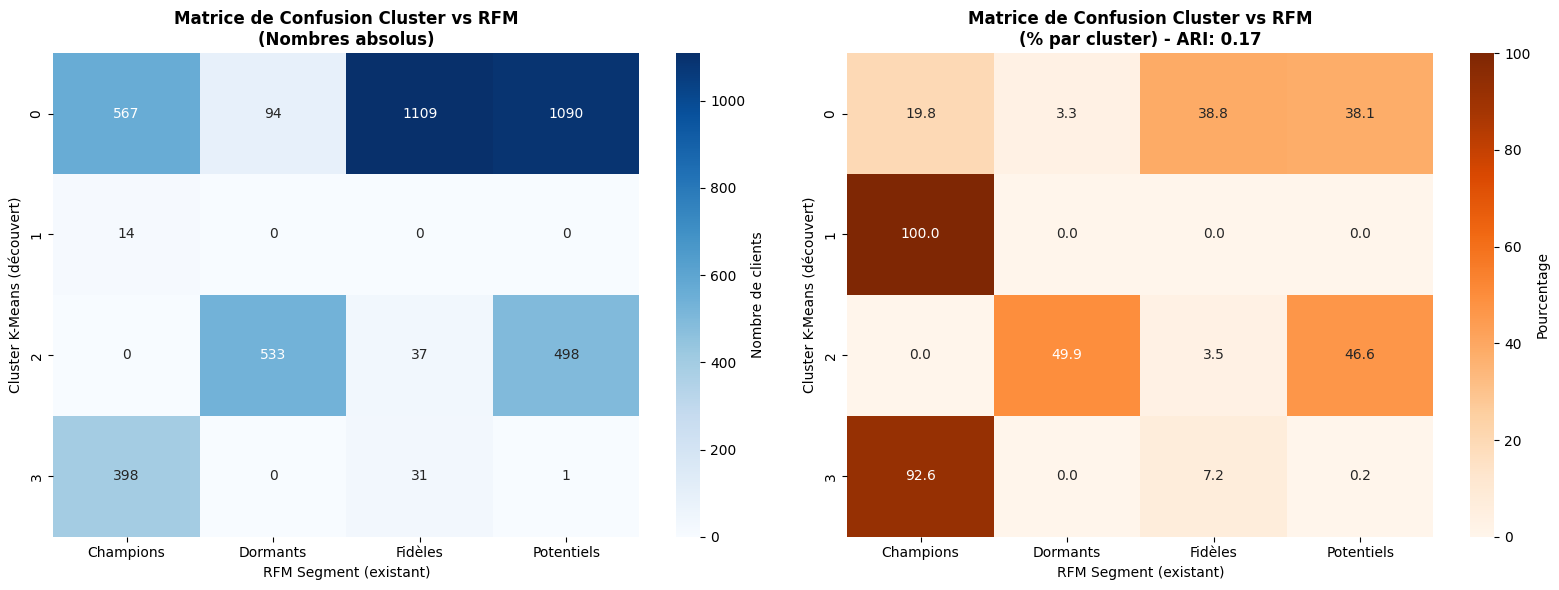


ANALYSE DES CORRESPONDANCES

🔹 Cluster 0 (n=2860):
   → Segment RFM dominant : Fidèles (38.8%)
   🔍 Nouveau segment transversal découvert !

🔹 Cluster 1 (n=14):
   → Segment RFM dominant : Champions (100.0%)
   ✅ Correspondance FORTE avec Champions

🔹 Cluster 2 (n=1068):
   → Segment RFM dominant : Dormants (49.9%)
   🔍 Nouveau segment transversal découvert !

🔹 Cluster 3 (n=430):
   → Segment RFM dominant : Champions (92.6%)
   ✅ Correspondance FORTE avec Champions

TABLEAU RÉCAPITULATIF
RFMSegment      Champions  Dormants  Fidèles  Potentiels  Total  %_Dominant
Cluster_KMeans                                                             
0                     567        94     1109        1090   2860       100.0
1                      14         0        0           0     14       100.0
2                       0       533       37         498   1068       100.0
3                     398         0       31           1    430       100.0


In [5]:
# ============================================
# CELLULE DE TEST CLUSTERING vs RFM SEGMENT
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, confusion_matrix

# 1. CHARGEMENT DES DONNÉES (adaptez le chemin)
# ------------------------------------------------
df = pd.read_csv(r'..\data\raw\retail_customers_COMPLETE CATEGORICAL.csv')  # Modifiez le chemin si besoin

print(f"Shape des données : {df.shape}")
print(f"Colonnes disponibles : {df.columns.tolist()[:10]}...")  # Aperçu

# 2. PRÉPARATION DES FEATURES POUR CLUSTERING
# ------------------------------------------------
features_clustering = [
    'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg',
    'CustomerTenure', 'TotalQuantity', 'UniqueProducts',
    'WeekendRatio', 'AvgDaysBetween'
]

# Vérification que les colonnes existent
features_available = [f for f in features_clustering if f in df.columns]
print(f"\nFeatures utilisées : {features_available}")

X = df[features_available].copy()

# Gestion des valeurs manquantes (simple imputation pour le test)
X = X.fillna(X.median())

# Standardisation (obligatoire pour K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. CLUSTERING K-MEANS
# ------------------------------------------------
n_clusters = 4  # Même nombre que les segments RFM (Champions, Fidèles, Potentiels, Dormants)
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

print(f"\nRépartition des clusters :")
print(df['Cluster_KMeans'].value_counts().sort_index())

# 4. MATRICE DE CONFUSION vs RFM SEGMENT
# ------------------------------------------------
if 'RFMSegment' in df.columns:
    # Création de la matrice de confusion croisée
    conf_matrix = pd.crosstab(
        df['Cluster_KMeans'], 
        df['RFMSegment'], 
        margins=True,
        normalize='index'  # Pourcentage par cluster (lignes)
    ) * 100
    
    # Calcul ARI (Adjusted Rand Index)
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    rfm_encoded = le.fit_transform(df['RFMSegment'])
    ari = adjusted_rand_score(rfm_encoded, df['Cluster_KMeans'])
    
    print(f"\n🎯 Adjusted Rand Index (ARI) : {ari:.3f}")
    print("   (1.0 = parfait, 0.0 = aléatoire, <0 = mauvais)")
    
    # 5. VISUALISATION
    # ------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap 1 : Nombres absolus
    conf_abs = pd.crosstab(df['Cluster_KMeans'], df['RFMSegment'])
    sns.heatmap(conf_abs, annot=True, fmt='d', cmap='Blues', 
                ax=axes[0], cbar_kws={'label': 'Nombre de clients'})
    axes[0].set_title('Matrice de Confusion Cluster vs RFM\n(Nombres absolus)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('RFM Segment (existant)')
    axes[0].set_ylabel('Cluster K-Means (découvert)')
    
    # Heatmap 2 : Pourcentages par cluster
    conf_pct = pd.crosstab(df['Cluster_KMeans'], df['RFMSegment'], normalize='index') * 100
    sns.heatmap(conf_pct, annot=True, fmt='.1f', cmap='Oranges', 
                ax=axes[1], cbar_kws={'label': 'Pourcentage'})
    axes[1].set_title(f'Matrice de Confusion Cluster vs RFM\n(% par cluster) - ARI: {ari:.2f}', 
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('RFM Segment (existant)')
    axes[1].set_ylabel('Cluster K-Means (découvert)')
    
    plt.tight_layout()
    plt.show()
    
    # 6. ANALYSE INTERPRÉTATION
    # ------------------------------------------------
    print("\n" + "="*60)
    print("ANALYSE DES CORRESPONDANCES")
    print("="*60)
    
    # Pour chaque cluster, trouver le segment RFM dominant
    for cluster in sorted(df['Cluster_KMeans'].unique()):
        cluster_data = df[df['Cluster_KMeans'] == cluster]
        dominant_segment = cluster_data['RFMSegment'].value_counts().index[0]
        purity = cluster_data['RFMSegment'].value_counts().iloc[0] / len(cluster_data) * 100
        
        print(f"\n🔹 Cluster {cluster} (n={len(cluster_data)}):")
        print(f"   → Segment RFM dominant : {dominant_segment} ({purity:.1f}%)")
        
        if purity > 80:
            print(f"   ✅ Correspondance FORTE avec {dominant_segment}")
        elif purity > 50:
            print(f"   ⚠️  Correspondance MODÉRÉE (mixte)")
        else:
            print(f"   🔍 Nouveau segment transversal découvert !")
    
    # Tableau récapitulatif
    print("\n" + "="*60)
    print("TABLEAU RÉCAPITULATIF")
    print("="*60)
    recap = pd.crosstab(df['Cluster_KMeans'], df['RFMSegment'])
    recap['Total'] = recap.sum(axis=1)
    recap['%_Dominant'] = recap.max(axis=1) / recap['Total'] * 100
    print(recap)
    
else:
    print("❌ Colonne 'RFMSegment' non trouvée dans les données!")
    print("   Affichage des clusters uniquement...")
    print(df['Cluster_KMeans'].value_counts())

✅ Clustering terminé !

Répartition des clients par cluster :
cluster
0     769
1     896
2    1545
3    1162
Name: count, dtype: int64

Taux de Churn par cluster (%) :
cluster
0     0.1
1     0.0
2    74.2
3    26.3
Name: churn, dtype: float64


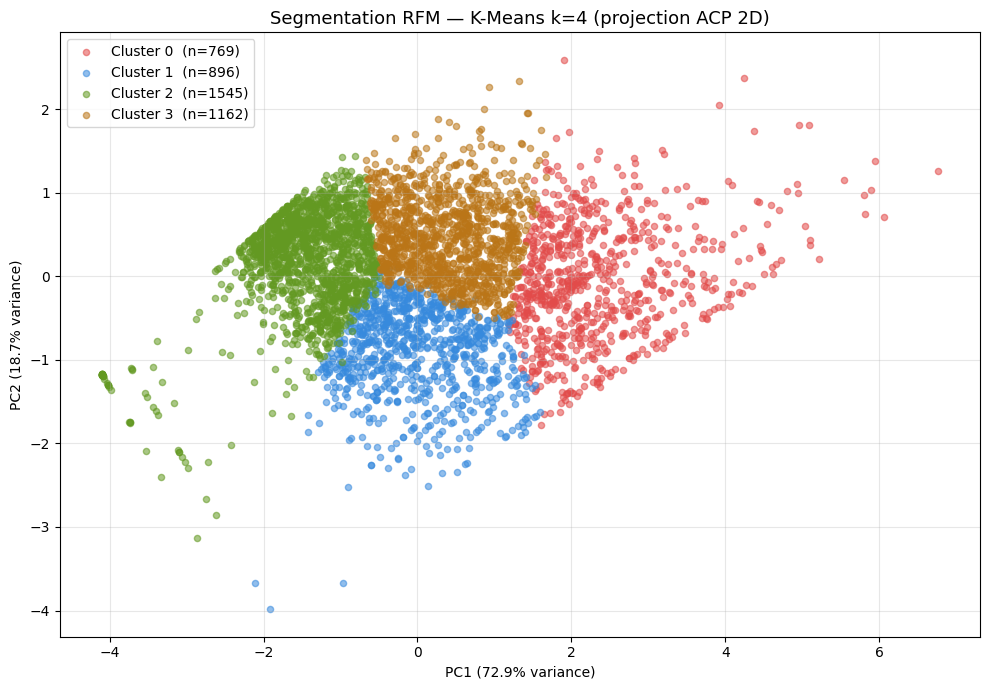

In [93]:
# ============================================================
# CELLULE 10 — K-Means RFM (k=4) + Visualisation ACP 2D
# ============================================================

# 1. K-Means sur les données log1p + scalées
kmeans_rfm = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_rfm.fit(X_rfm_scaled)

# 2. Construction du dataframe de clustering
df_clust = df_rfm_raw.copy()
df_clust.columns = ['Recency', 'Frequency', 'MonetaryTotal', 'churn']
df_clust['cluster'] = kmeans_rfm.labels_

print("✅ Clustering terminé !")
print(f"\nRépartition des clients par cluster :")
print(df_clust['cluster'].value_counts().sort_index())
print(f"\nTaux de Churn par cluster (%) :")
print((df_clust.groupby('cluster')['churn'].mean() * 100).round(1))

# 3. ACP 2D pour visualisation uniquement
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_rfm_scaled)

colors = ['#E24B4A', '#378ADD', '#639922', '#BA7517']

plt.figure(figsize=(10, 7))
for i in range(k_optimal):
    mask_c = df_clust['cluster'] == i
    plt.scatter(
        X_2d[mask_c, 0], X_2d[mask_c, 1],
        c=colors[i], label=f'Cluster {i}  (n={mask_c.sum()})',
        alpha=0.55, s=20
    )

plt.title('Segmentation RFM — K-Means k=4 (projection ACP 2D)', fontsize=13)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [94]:
# ============================================================
# CELLULE 11 — Profils des Clusters (métriques RFM + Churn)
# ============================================================
rfm_cols = ['Recency', 'Frequency', 'MonetaryTotal', 'churn']

cluster_profiles = df_clust.groupby('cluster')[rfm_cols].mean().round(2)
cluster_profiles['nb_clients'] = df_clust['cluster'].value_counts().sort_index()
cluster_profiles['pct_clients'] = (
    cluster_profiles['nb_clients'] / len(df_clust) * 100
).round(1)
cluster_profiles['churn_pct'] = (cluster_profiles['churn'] * 100).round(1)
cluster_profiles = cluster_profiles.drop(columns=['churn'])

print("=" * 60)
print("         PROFILS DES CLUSTERS — RFM")
print("=" * 60)
print(cluster_profiles.to_string())
print("=" * 60)

         PROFILS DES CLUSTERS — RFM
         Recency  Frequency  MonetaryTotal  nb_clients  pct_clients  churn_pct
cluster                                                                       
0          11.10      15.99        7134.58         769         17.6        0.0
1          19.17       2.29         555.31         896         20.5        0.0
2         187.63       1.43         305.85        1545         35.3       74.0
3          74.72       4.85        1586.47        1162         26.6       26.0


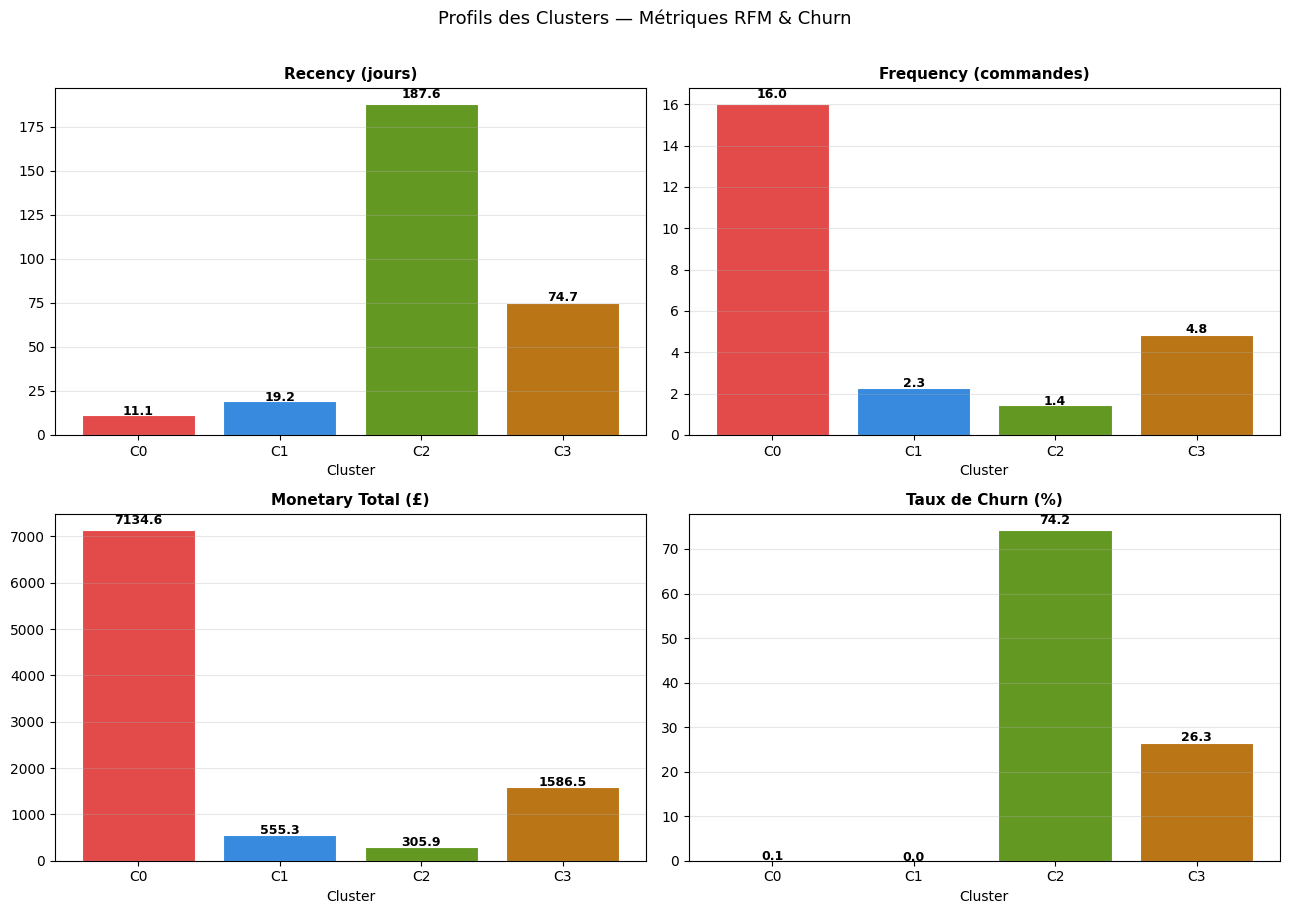

In [95]:
# ============================================================
# CELLULE 12 — Visualisation des Profils (barplots)
# ============================================================
colors = ['#E24B4A', '#378ADD', '#639922', '#BA7517']

metrics = ['Recency', 'Frequency', 'MonetaryTotal', 'churn']
titles  = ['Recency (jours)', 'Frequency (commandes)',
           'Monetary Total (£)', 'Taux de Churn (%)']
scales  = [1, 1, 1, 100]  # churn en %

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, metric, title, scale in zip(axes.flatten(), metrics, titles, scales):
    vals = df_clust.groupby('cluster')[metric].mean() * scale
    bars = ax.bar(range(k_optimal), vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_xticks(range(k_optimal))
    ax.set_xticklabels([f'C{i}' for i in range(k_optimal)])
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Profils des Clusters — Métriques RFM & Churn', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# CELLULE 13 — Nommage des Segments RFM
# ============================================================
# Logique basée sur churn_pct (prioritaire) puis Frequency :
#
#  churn >= 60%              → Clients Perdus
#  churn >= 15%              → Clients à Risque
#  churn < 15% + Freq >= 8  → Clients Champions
#  churn < 15% + Freq < 8   → Clients Fidèles

print("Référence pour nommer les segments :")
print(cluster_profiles[['Recency', 'Frequency', 'MonetaryTotal', 'churn_pct', 'pct_clients']])
print()

# Nommage automatique
def auto_name(row):                          # ← plus besoin de all_recency
    if row['churn_pct'] >= 60:
        return 'Clients Perdus'
    elif row['churn_pct'] >= 15:
        return 'Clients à Risque'
    elif row['Frequency'] >= 8:
        return 'Clients Champions'
    else:
        return 'Clients Réguliers'

cluster_profiles['segment'] = cluster_profiles.apply(
    auto_name, axis=1                        # ← lambda r: auto_name(r, ...) supprimé
)
segment_map = cluster_profiles['segment'].to_dict()
df_clust['segment'] = df_clust['cluster'].map(segment_map)

print(" Segments attribués :")
print(cluster_profiles[['churn_pct', 'Frequency', 'segment']].to_string())
print("\nDistribution des segments :")
print(df_clust['segment'].value_counts())

Référence pour nommer les segments :
         Recency  Frequency  MonetaryTotal  churn_pct  pct_clients
cluster                                                           
0          11.10      15.99        7134.58        0.0         17.6
1          19.17       2.29         555.31        0.0         20.5
2         187.63       1.43         305.85       74.0         35.3
3          74.72       4.85        1586.47       26.0         26.6

 Segments attribués :
         churn_pct  Frequency            segment
cluster                                         
0              0.0      15.99  Clients Champions
1              0.0       2.29  Clients Réguliers
2             74.0       1.43     Clients Perdus
3             26.0       4.85   Clients à Risque

Distribution des segments :
segment
Clients Perdus       1545
Clients à Risque     1162
Clients Réguliers     896
Clients Champions     769
Name: count, dtype: int64


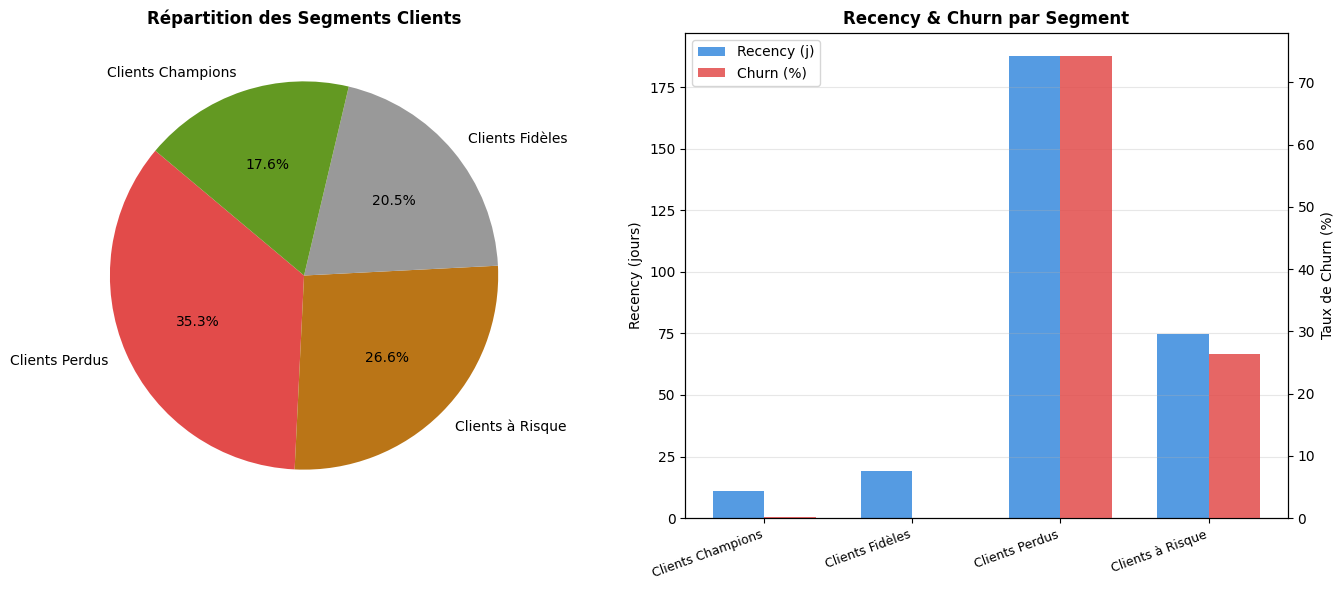


✅ Modèles RFM sauvegardés.


In [ ]:
# ============================================================
# CELLULE 14 — Visualisation des Segments (Radar Chart + Pie)
# ============================================================
from matplotlib.patches import FancyBboxPatch

segment_colors = {
    'Clients Champions' : '#639922',
    'Clients Réguliers' : '#378ADD',
    'Clients à Risque'  : '#BA7517',
    'Clients Perdus'    : '#E24B4A',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Pie : répartition des segments ---
seg_counts = df_clust['segment'].value_counts()
seg_cols   = [segment_colors.get(s, '#999') for s in seg_counts.index]
axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=seg_cols,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 10}
)
axes[0].set_title('Répartition des Segments Clients', fontsize=12, fontweight='bold')

# --- Barplot groupé : Recency & Churn par segment ---
seg_profile = df_clust.groupby('segment')[['Recency', 'churn']].mean()
seg_profile['churn'] *= 100
x = np.arange(len(seg_profile))
width = 0.35

b1 = axes[1].bar(x - width/2, seg_profile['Recency'],  width, label='Recency (j)',   color='#378ADD', alpha=0.85)
ax2 = axes[1].twinx()
b2 = ax2.bar(x + width/2, seg_profile['churn'], width, label='Churn (%)', color='#E24B4A', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_profile.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Recency (jours)')
ax2.set_ylabel('Taux de Churn (%)')
axes[1].set_title('Recency & Churn par Segment', fontsize=12, fontweight='bold')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Sauvegarde
joblib.dump(kmeans_rfm, r'C:\Users\abdal\Desktop\projects\ML\ML_project\models\kmeans_rfm.pkl')
joblib.dump(scaler_rfm, r'C:\Users\abdal\Desktop\projects\ML\ML_project\models\scaler_rfm.pkl')
print("\n✅ Modèles RFM sauvegardés.")

---
## Partie 3 — Classification (Prédiction du Churn)

> Cette partie utilise **toutes les features** (après preprocessing) avec ACP
> puis applique des modèles supervisés pour prédire le churn.

Features supprimées avant ACP : ['Recency', 'FirstPurchaseDaysAgo', 'CustomerTenureDays', 'LoyaltyLevel']
X_train shape : (3169, 52)
Avant ACP  : 52 features
Après ACP  : 28 composantes
Variance expliquée : 95.07%


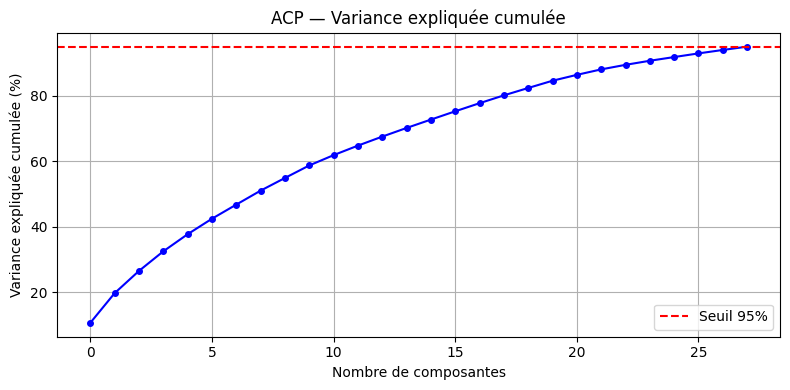

PCA sauvegardée


In [ ]:
# ============================================================
# CELLULE 15 — ACP pour la Classification
# ============================================================
# fit sur X_train SEULEMENT → transform sur X_test
# n_components=0.95 → garde les composantes qui expliquent 95% de la variance
# ← AJOUTER CES LIGNES AVANT L'ACP
cols_leakage_classification = ['Recency',
                               'FirstPurchaseDaysAgo',   # durée depuis 1er achat = proxy de tenure
    'CustomerTenureDays',     # durée de vie client = quasi-identique à Recency
    'LoyaltyLevel',        ]   # construit à partir de CustomerTenureDays      # conséquence du churn, pas une cause
X_train = X_train.drop(columns=[c for c in cols_leakage_classification if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in cols_leakage_classification if c in X_test.columns])
print(f"Features supprimées avant ACP : {cols_leakage_classification}")
print(f"X_train shape : {X_train.shape}")

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f'Avant ACP  : {X_train.shape[1]} features')
print(f'Après ACP  : {pca.n_components_} composantes')
print(f'Variance expliquée : {pca.explained_variance_ratio_.sum():.2%}')

# Visualisation variance cumulée
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, 'b-o', markersize=4)
plt.axhline(y=95, color='r', linestyle='--', label='Seuil 95%')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée (%)')
plt.title('ACP — Variance expliquée cumulée')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

joblib.dump(pca, r'C:\Users\abdal\Desktop\projects\ML\ML_project\models\pca.pkl')
print('PCA sauvegardée')

In [ ]:
# ============================================================
# CELLULE 16 — SMOTE : Rééquilibrage des classes
# ============================================================
# SMOTE génère des exemples synthétiques de la classe minoritaire
# (Churn=1) pour équilibrer le dataset d'entraînement.
# APRÈS le split → évite la contamination du test set.
# Deux versions :
#   X_train_bal    → sur X_train_pca  (pour RF avec ACP)
#   X_train_bal_rf → sur X_train      (pour RF sans ACP)

from imblearn.over_sampling import SMOTE

print('Distribution avant SMOTE :')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_bal,    y_train_bal    = smote.fit_resample(X_train_pca, y_train)
X_train_bal_rf, y_train_bal_rf = smote.fit_resample(X_train,     y_train)

print(f'\nAprès SMOTE (avec ACP)  : {X_train_bal.shape}')
print(pd.Series(y_train_bal).value_counts())
print(f'\nAprès SMOTE (sans ACP)  : {X_train_bal_rf.shape}')
print(pd.Series(y_train_bal_rf).value_counts())

Distribution avant SMOTE :
Churn
0    2127
1    1042
Name: count, dtype: int64

Après SMOTE (avec ACP)  : (4254, 28)
Churn
0    2127
1    2127
Name: count, dtype: int64

Après SMOTE (sans ACP)  : (4254, 52)
Churn
0    2127
1    2127
Name: count, dtype: int64


=== Random Forest SANS ACP ===
              precision    recall  f1-score   support

      Fidèle       0.91      0.93      0.92       584
       Parti       0.86      0.81      0.84       291

    accuracy                           0.89       875
   macro avg       0.89      0.87      0.88       875
weighted avg       0.89      0.89      0.89       875

Accuracy : 0.8949
F1 Score : 0.8375
AUC-ROC  : 0.8747


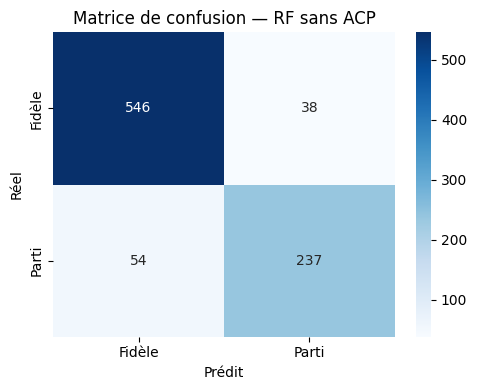

In [ ]:
# ============================================================
# CELLULE 17 — Random Forest SANS ACP
# ============================================================
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf.fit(X_train_bal_rf, y_train_bal_rf)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest SANS ACP ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['Fidèle', 'Parti']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_pred_rf):.4f}')

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'])
plt.title('Matrice de confusion — RF sans ACP')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELLULE 18 — Feature Importance
# ============================================================
importances = pd.Series(
    rf.feature_importances_,
    index=X_.columns
).sort_values(ascending=False)

top20 = importances.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index,
            hue=top20.index, palette='Blues_r', legend=False)
plt.title('Top 20 Features — Random Forest sans ACP')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

print('Top 10 features :')
print(top20.head(10).to_string())

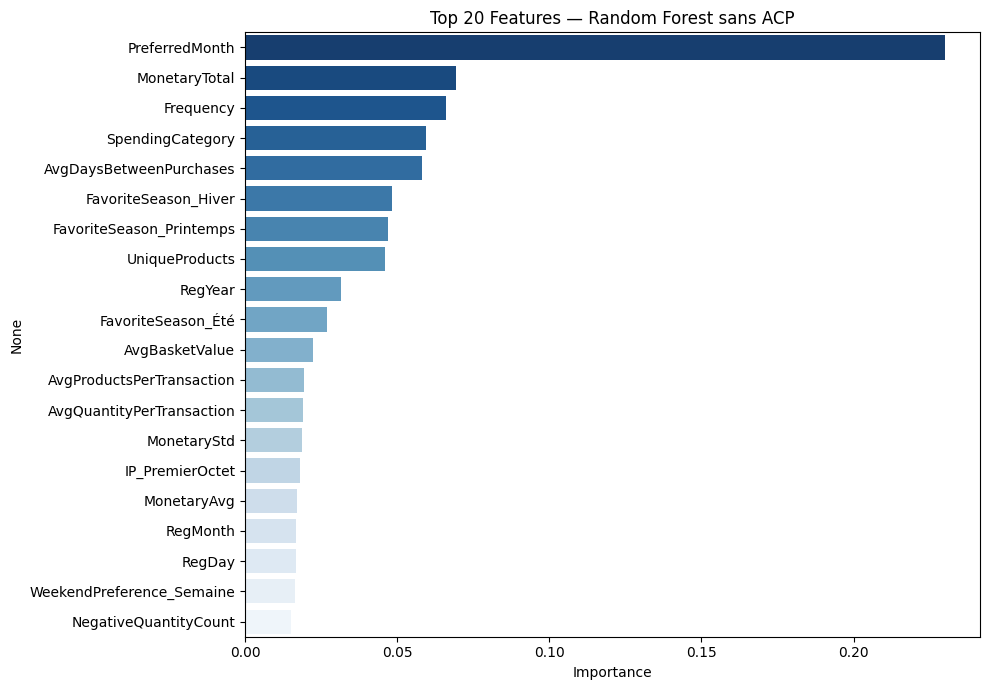

Top 10 features :
PreferredMonth              0.230033
MonetaryTotal               0.069293
Frequency                   0.065984
SpendingCategory            0.059314
AvgDaysBetweenPurchases     0.058069
FavoriteSeason_Hiver        0.048454
FavoriteSeason_Printemps    0.047091
UniqueProducts              0.045980
RegYear                     0.031460
FavoriteSeason_Été          0.026908


In [ ]:
# ============================================================
# CELLULE 18 — Feature Importance
# ============================================================
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top20 = importances.head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=top20.values, y=top20.index,
            hue=top20.index, palette='Blues_r', legend=False)
plt.title('Top 20 Features — Random Forest sans ACP')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

print('Top 10 features :')
print(top20.head(10).to_string())

=== Random Forest AVEC ACP ===
              precision    recall  f1-score   support

      Fidèle       0.90      0.93      0.91       584
       Parti       0.84      0.78      0.81       291

    accuracy                           0.88       875
   macro avg       0.87      0.85      0.86       875
weighted avg       0.88      0.88      0.88       875

Accuracy : 0.8789
F1 Score : 0.8114
AUC-ROC  : 0.8549


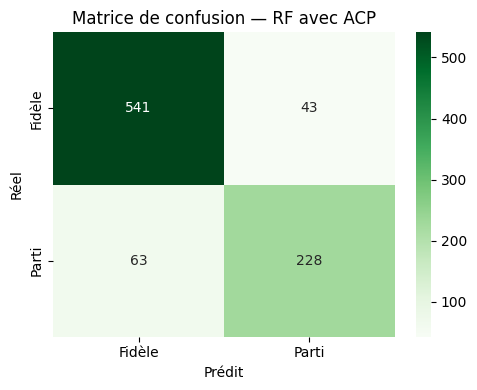

In [ ]:
# ============================================================
# CELLULE 19 — Random Forest AVEC ACP
# ============================================================
rf_pca = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_pca.fit(X_train_bal, y_train_bal)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

print('=== Random Forest AVEC ACP ===')
print(classification_report(y_test, y_pred_rf_pca,
      target_names=['Fidèle', 'Parti']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf_pca):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_rf_pca):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_pred_rf_pca):.4f}')

cm_pca = confusion_matrix(y_test, y_pred_rf_pca)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'])
plt.title('Matrice de confusion — RF avec ACP')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

=== Régression Logistique ===
              precision    recall  f1-score   support

      Fidèle       0.94      0.86      0.90       584
       Parti       0.76      0.90      0.82       291

    accuracy                           0.87       875
   macro avg       0.85      0.88      0.86       875
weighted avg       0.88      0.87      0.87       875

Accuracy : 0.8720
F1 Score : 0.8233
AUC-ROC  : 0.8782


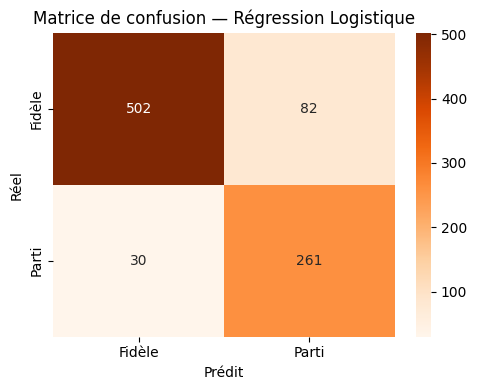

In [ ]:
# ============================================================
# CELLULE 20 — Régression Logistique
# ============================================================
lr = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
lr.fit(X_train_bal_rf, y_train_bal_rf)
y_pred_lr = lr.predict(X_test)

print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_lr,
      target_names=['Fidèle', 'Parti']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_pred_lr):.4f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'])
plt.title('Matrice de confusion — Régression Logistique')
plt.xlabel('Prédit'); plt.ylabel('Réel')
plt.tight_layout(); plt.show()

Recherche des meilleurs hyperparamètres... (2-3 min)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Meilleurs paramètres  : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur AUC-ROC (CV) : 98.4%

=== Meilleur RF (GridSearchCV) ===
              precision    recall  f1-score   support

      Fidèle       0.91      0.94      0.92       584
       Parti       0.87      0.81      0.84       291

    accuracy                           0.90       875
   macro avg       0.89      0.88      0.88       875
weighted avg       0.90      0.90      0.90       875

Accuracy : 0.8971
F1 Score : 0.8404
AUC-ROC  : 0.8764


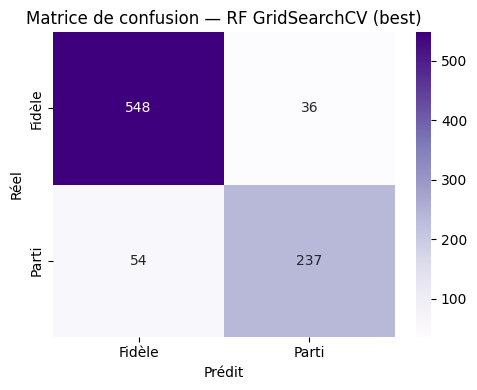

In [ ]:
# ============================================================
# CELLULE 21 — GridSearchCV (optimisation hyperparamètres)
# ============================================================
# Teste toutes les combinaisons + validation croisée cv=5
# scoring='roc_auc' → optimise pour les classes déséquilibrées

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5]
}

print('Recherche des meilleurs hyperparamètres... (2-3 min)')

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_bal_rf, y_train_bal_rf)

print(f'\nMeilleurs paramètres  : {grid_search.best_params_}')
print(f'Meilleur AUC-ROC (CV) : {grid_search.best_score_*100:.1f}%')

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print('\n=== Meilleur RF (GridSearchCV) ===')
print(classification_report(y_test, y_pred_best,
      target_names=['Fidèle', 'Parti']))
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_best):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_pred_best):.4f}')

# ← AJOUT : matrice de confusion
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Fidèle', 'Parti'],
            yticklabels=['Fidèle', 'Parti'])
plt.title('Matrice de confusion — RF GridSearchCV (best)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

                Modèle  Accuracy  F1 Score  AUC-ROC
           RF sans ACP    0.8949    0.8375   0.8747
           RF avec ACP    0.8789    0.8114   0.8549
 Régression Logistique    0.8720    0.8233   0.8782
RF GridSearchCV (best)    0.8971    0.8404   0.8764


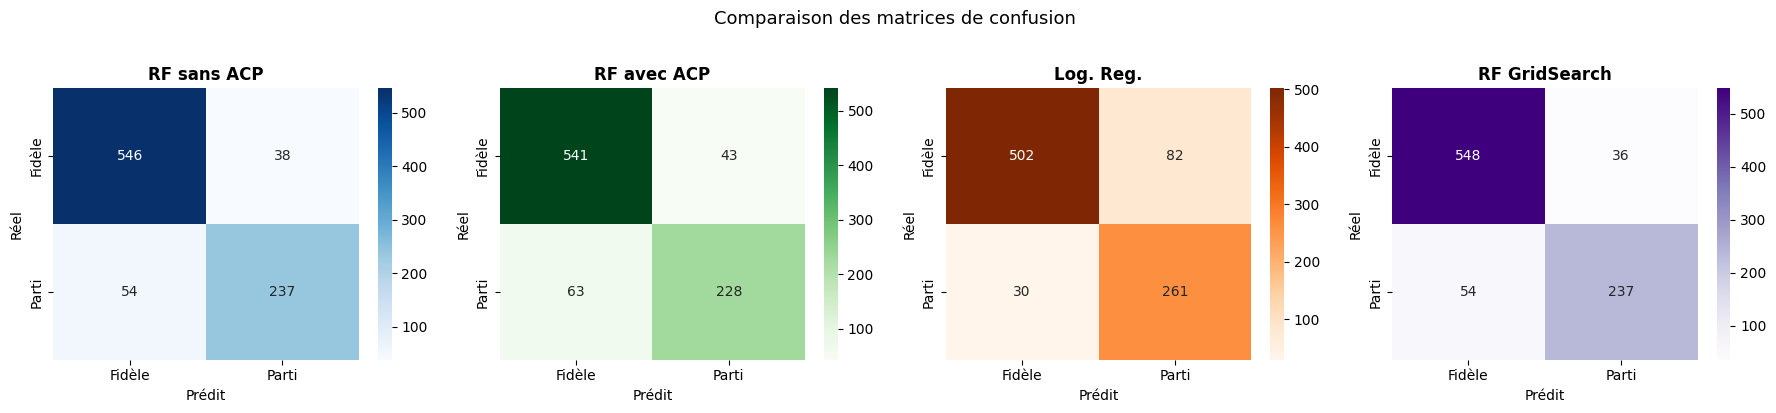


Tout sauvegardé !
  models/ → random_forest_churn.pkl, pca.pkl, scaler.pkl, imputer.pkl, feature_columns.pkl
  data/train_test/ → X_train, X_test, y_train, y_test


In [ ]:
# ============================================================
# CELLULE 22
# — Comparaison des modèles + Sauvegarde
# ============================================================
resultats = pd.DataFrame({
    'Modèle': [
        'RF sans ACP',
        'RF avec ACP',
        'Régression Logistique',
        'RF GridSearchCV (best)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_pca),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_best)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_pca),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_best)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_pred_rf_pca),
        roc_auc_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_pred_best)
    ]
})

print(resultats.round(4).to_string(index=False))

# ── Sauvegarde ──────────────────────────────────────────────
models_path = r'C:\Users\abdal\Desktop\projects\ML\ML_project\models'
data_path   = r'C:\Users\abdal\Desktop\projects\ML\ML_project\data\train_test'
os.makedirs(models_path, exist_ok=True)
os.makedirs(data_path,   exist_ok=True)

joblib.dump(best_rf,                  models_path + r'\random_forest_churn.pkl')
joblib.dump(pca,                      models_path + r'\pca.pkl')
joblib.dump(scaler,                   models_path + r'\scaler.pkl')
joblib.dump(imputer,                  models_path + r'\imputer.pkl')
joblib.dump(X_train.columns.tolist(), models_path + r'\feature_columns.pkl')

X_train.to_csv(data_path + r'\X_train.csv', index=False)
X_test.to_csv( data_path + r'\X_test.csv',  index=False)
y_train.to_csv(data_path + r'\y_train.csv', index=False)
y_test.to_csv( data_path + r'\y_test.csv',  index=False)

# Comparaison visuelle des 4 matrices de confusion
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

configs = [
    (confusion_matrix(y_test, y_pred_rf),     'RF sans ACP',   'Blues'),
    (confusion_matrix(y_test, y_pred_rf_pca), 'RF avec ACP',   'Greens'),
    (confusion_matrix(y_test, y_pred_lr),     'Log. Reg.',     'Oranges'),
    (confusion_matrix(y_test, y_pred_best),   'RF GridSearch', 'Purples'),
]

for ax, (cm, titre, cmap) in zip(axes, configs):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Fidèle', 'Parti'],
                yticklabels=['Fidèle', 'Parti'])
    ax.set_title(titre, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Comparaison des matrices de confusion', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nTout sauvegardé !')
print(f'  models/ → random_forest_churn.pkl, pca.pkl, scaler.pkl, imputer.pkl, feature_columns.pkl')
print(f'  data/train_test/ → X_train, X_test, y_train, y_test')

## Partie 4 — Regression


In [81]:
# ============================================================
# CELLULE 16 — Régression : Prédiction du MonetaryTotal futur
# ============================================================
# Objectif : estimer le CA futur d'un client (£)
# Target   : MonetaryTotal  (variable continue)
# Modèles  : Régression Linéaire (baseline) vs RF Regressor
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')
 
# Suppression colonnes non pertinentes pour la régression
reg_drop = ['Churn', 'CustomerID',
            'Recency', 'FirstPurchaseDaysAgo',
            'CustomerTenureDays', 'LoyaltyLevel', 'Frequency']
 
df_reg = df_clean.drop(columns=[c for c in reg_drop if c in df_clean.columns])
df_reg = df_reg.select_dtypes(include='number')     # garder uniquement numérique
 
y_reg = df_reg['MonetaryTotal']
X_reg = df_reg.drop(columns=['MonetaryTotal'])
 
print(f"Shape X_reg : {X_reg.shape}")
print(f"\nTarget MonetaryTotal :")
print(y_reg.describe().round(1))
 
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
 
# Imputation + Scaling (fit sur train SEULEMENT)
imp_reg = SimpleImputer(strategy='median')
X_reg_train = pd.DataFrame(imp_reg.fit_transform(X_reg_train), columns=X_reg_train.columns)
X_reg_test  = pd.DataFrame(imp_reg.transform(X_reg_test),      columns=X_reg_test.columns)
 
scaler_reg = StandardScaler()
X_reg_tr_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_te_sc = scaler_reg.transform(X_reg_test)
 
print(f"\nSplit — Train : {X_reg_train.shape} | Test : {X_reg_test.shape}")

Shape X_reg : (4372, 28)

Target MonetaryTotal :
count      4372.0
mean       1898.5
std        8219.3
min       -4287.6
25%         293.4
50%         648.1
75%        1611.7
max      279489.0
Name: MonetaryTotal, dtype: float64

Split — Train : (3497, 28) | Test : (875, 28)


In [82]:
# ============================================================
# CELLULE 17 — Entraînement et comparaison des modèles 
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import pandas as pd

# 1. Régression Linéaire (baseline)
lr_reg = LinearRegression()
lr_reg.fit(X_reg_tr_sc, y_reg_train)
y_pred_lr_reg = lr_reg.predict(X_reg_te_sc)

mae_lr  = mean_absolute_error(y_reg_test, y_pred_lr_reg)
rmse_lr = root_mean_squared_error(y_reg_test, y_pred_lr_reg) # Utilisation de la nouvelle fonction
r2_lr   = r2_score(y_reg_test, y_pred_lr_reg)

print("=== Régression Linéaire (baseline) ===")
print(f"MAE  : {mae_lr:.1f} £")
print(f"RMSE : {rmse_lr:.1f} £")
print(f"R²   : {r2_lr:.4f}")

# 2. Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100, max_depth=15,
    min_samples_split=5, random_state=42, n_jobs=-1
)
rf_reg.fit(X_reg_train, y_reg_train)
y_pred_rf_reg = rf_reg.predict(X_reg_test)

mae_rf  = mean_absolute_error(y_reg_test, y_pred_rf_reg)
# CORRECTION SYNTAXE ICI (Retour à la ligne entre RMSE et R2)
rmse_rf = root_mean_squared_error(y_reg_test, y_pred_rf_reg)
r2_rf   = r2_score(y_reg_test, y_pred_rf_reg)

print("\n=== Random Forest Regressor ===")
print(f"MAE  : {mae_rf:.1f} £")
print(f"RMSE : {rmse_rf:.1f} £")
print(f"R²   : {r2_rf:.4f}")

# Tableau comparatif
resultats_reg = pd.DataFrame({
    'Modèle'  : ['Régression Linéaire', 'RF Regressor'],
    'MAE (£)' : [round(mae_lr,1),  round(mae_rf,1)],
    'RMSE (£)': [round(rmse_lr,1), round(rmse_rf,1)],
    'R²'      : [round(r2_lr,4),   round(r2_rf,4)]
})
print(f"\n── Comparaison ──────────────")
print(resultats_reg.to_string(index=False))

=== Régression Linéaire (baseline) ===
MAE  : 1881.8 £
RMSE : 9698.8 £
R²   : 0.2690

=== Random Forest Regressor ===
MAE  : 965.3 £
RMSE : 9299.1 £
R²   : 0.3280

── Comparaison ──────────────
             Modèle  MAE (£)  RMSE (£)    R²
Régression Linéaire   1881.8    9698.8 0.269
       RF Regressor    965.3    9299.1 0.328


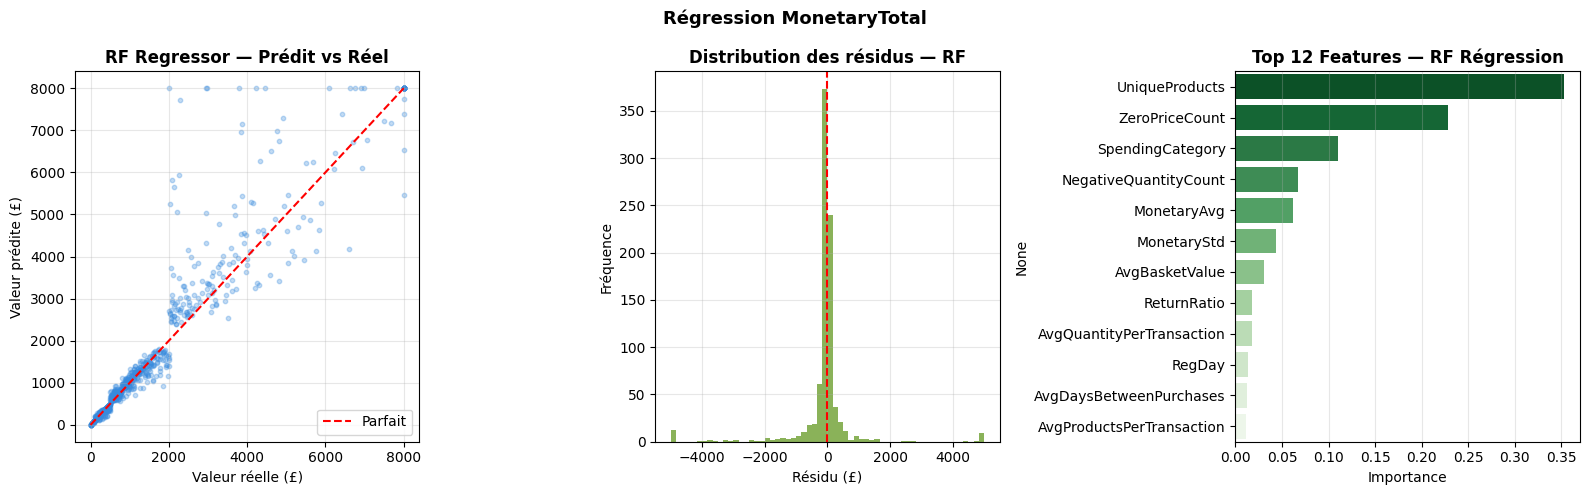


✅ Modèles de régression sauvegardés.


In [83]:
# ============================================================
# CELLULE 18 — Visualisations de la régression
# ============================================================
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# Graphe 1 : Prédit vs Réel (RF)
y_test_clip = np.clip(y_reg_test, 0, 8000)
y_pred_clip = np.clip(y_pred_rf_reg, 0, 8000)
 
axes[0].scatter(y_test_clip, y_pred_clip, alpha=0.3, s=10, color='#378ADD')
axes[0].plot([0, 8000], [0, 8000], 'r--', lw=1.5, label='Parfait')
axes[0].set_xlabel('Valeur réelle (£)')
axes[0].set_ylabel('Valeur prédite (£)')
axes[0].set_title('RF Regressor — Prédit vs Réel', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
 
# Graphe 2 : Distribution des résidus
residus = np.clip(y_reg_test.values - y_pred_rf_reg, -5000, 5000)
axes[1].hist(residus, bins=60, color='#639922', alpha=0.75)
axes[1].axvline(x=0, color='r', linestyle='--', lw=1.5)
axes[1].set_xlabel('Résidu (£)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus — RF', fontweight='bold')
axes[1].grid(True, alpha=0.3)
 
# Graphe 3 : Feature importance RF
imp_reg_s = pd.Series(rf_reg.feature_importances_,
                      index=X_reg_train.columns).sort_values(ascending=False).head(12)
sns.barplot(x=imp_reg_s.values, y=imp_reg_s.index,
            hue=imp_reg_s.index, palette='Greens_r', legend=False, ax=axes[2])
axes[2].set_title('Top 12 Features — RF Régression', fontweight='bold')
axes[2].set_xlabel('Importance'); axes[2].grid(axis='x', alpha=0.3)
 
plt.suptitle('Régression MonetaryTotal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Sauvegarde
models_path = r'C:\Users\abdal\Desktop\projects\ML\ML_project\models'
joblib.dump(rf_reg,     models_path + r'\rf_regressor.pkl')
joblib.dump(imp_reg,    models_path + r'\imputer_reg.pkl')
joblib.dump(scaler_reg, models_path + r'\scaler_reg.pkl')
joblib.dump(X_reg_train.columns.tolist(), models_path + r'\feature_columns_reg.pkl')
print("\n✅ Modèles de régression sauvegardés.")

In [11]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# =========================================================
# 1. PRÉPARATION DES DONNÉES POUR LE MATCH
# =========================================================
print("⚙️ Préparation des données...")
TARGET = 'MonetaryTotal' # Mettez 'monetarytotal' en minuscules si votre df a été mis en minuscules

# Récupération et filtrage des NaN
y_train = df.loc[X_train.index, TARGET]
y_test  = df.loc[X_test.index, TARGET]

mask_train_valide = y_train.notna()
mask_test_valide  = y_test.notna()

y_train_reg = y_train[mask_train_valide]
y_test_reg  = y_test[mask_test_valide]

X_train_reg = X_train[mask_train_valide].copy()
X_test_reg  = X_test[mask_test_valide].copy()

# Suppression de la cible dans les indices (anti-triche)
X_train_reg = X_train_reg.drop(columns=[TARGET], errors='ignore')
X_test_reg  = X_test_reg.drop(columns=[TARGET], errors='ignore')

# Transformation Logarithmique
y_train_reg_log = np.log1p(y_train_reg)
y_test_reg_log  = np.log1p(y_test_reg)

# =========================================================
# 2. DÉFINITION DES MÉTRIQUES
# =========================================================
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100

def calculate_rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred))**2))

# =========================================================
# 3. LE MATCH : RANDOM FOREST vs XGBOOST
# =========================================================
print("\n🥊 DÉBUT DU MATCH : Random Forest vs XGBoost\n")

# Entraînement de Random Forest
print("⏳ Entraînement de Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_reg, y_train_reg_log) 
y_pred_rf_log = rf.predict(X_test_reg)
y_pred_rf = np.expm1(y_pred_rf_log)  

# Entraînement de XGBoost
print("⏳ Entraînement de XGBoost...")
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
xgb.fit(X_train_reg, y_train_reg_log) 
y_pred_xgb_log = xgb.predict(X_test_reg)
y_pred_xgb = np.expm1(y_pred_xgb_log) 

# =========================================================
# 4. RÉSULTATS
# =========================================================
modeles = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

print("\n📊 RÉSULTATS DU MATCH (Échelle réelle en Euros) :")
print("-" * 75)
print(f"{'Modèle':<15} | {'R² (↑)':<8} | {'MAE (↓)':<10} | {'RMSE (↓)':<10} | {'MAPE (↓)':<10} | {'RMSLE (↓)':<10}")
print("-" * 75)

for nom, y_pred in modeles.items():
    r2 = r2_score(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mape = calculate_mape(y_test_reg, y_pred)
    rmsle = calculate_rmsle(y_test_reg, y_pred)
    
    print(f"{nom:<15} | {r2:<8.3f} | {mae:<10.1f} | {rmse:<10.1f} | {mape:<8.1f}% | {rmsle:<10.3f}")
print("-" * 75)
print("Note : (↑) Plus haut c'est mieux | (↓) Plus bas c'est mieux")

⚙️ Préparation des données...

🥊 DÉBUT DU MATCH : Random Forest vs XGBoost

⏳ Entraînement de Random Forest...


ValueError: could not convert string to float: 'United Kingdom'